# Modeling NBA 2025-26

Fase 4 del proceso CRISP-DM. Se entrenan cuatro modelos para regresión y tres para clasificación, se buscan los mejores hiperparámetros con validación cruzada temporal y se selecciona el modelo final basándose en las métricas del conjunto de test, que no se toca durante el entrenamiento.

## Carga de datos procesados

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import scipy.stats as stats
warnings.filterwarnings('ignore')

from sklearn.dummy        import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble     import RandomForestClassifier, RandomForestRegressor
from sklearn.calibration  import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline     import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.inspection   import permutation_importance
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              mean_squared_error, mean_absolute_error, r2_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier, XGBRegressor

sns.set_theme(style='whitegrid')

PROC = '../data/processed/'
team_train   = pd.read_csv(PROC + 'team_classification_train.csv',  parse_dates=['game_date'])
team_test    = pd.read_csv(PROC + 'team_classification_test.csv',   parse_dates=['game_date'])
player_train = pd.read_csv(PROC + 'player_regression_train.csv',    parse_dates=['game_date'])
player_test  = pd.read_csv(PROC + 'player_regression_test.csv',     parse_dates=['game_date'])

TEAM_FEATS   = [c for c in team_train.columns
                if c not in ['game_id', 'team_id', 'game_date', 'target']]
PLAYER_FEATS = [c for c in player_train.columns
                if c not in ['game_id', 'player_id', 'team_id', 'game_date', 'target']]

X_tt, y_tt = team_train[TEAM_FEATS].values,     team_train['target'].values
X_te, y_te = team_test[TEAM_FEATS].values,      team_test['target'].values
X_pt, y_pt = player_train[PLAYER_FEATS].values, player_train['target'].values
X_pe, y_pe = player_test[PLAYER_FEATS].values,  player_test['target'].values

new_team_feat   = ['streak', 'rest_days', 'home_winrate', 'away_winrate',
                   'net_rating_last5', 'opp_pts_last5']
new_player_feat = ['min_dec_last5', 'pts_trend', 'shot_volume_last5', 'position']

pd.DataFrame({
    'total_features':   [len(TEAM_FEATS), len(PLAYER_FEATS)],
    'nuevos_presentes': [sum(c in TEAM_FEATS   for c in new_team_feat),
                         sum(c in PLAYER_FEATS for c in new_player_feat)],
    'filas_train':      [len(team_train),  len(player_train)],
    'filas_test':       [len(team_test),   len(player_test)]
}, index=['clasificacion', 'regresion'])

## Validación cruzada temporal

En datos con estructura temporal, la validación cruzada estándar introduce data leakage: partidos del futuro pueden quedar en el conjunto de entrenamiento y partidos del pasado en el de validación, generando métricas infladas que no se replican en producción.

`TimeSeriesSplit` con 5 folds garantiza que en cada iteración el conjunto de entrenamiento contiene únicamente partidos anteriores al corte temporal. La ventana de entrenamiento crece en cada fold y el conjunto de validación siempre es estrictamente posterior.

**Problema que evita frente al split aleatorio:** en una temporada NBA de 82 partidos por equipo, la forma del equipo cambia progresivamente. Un split aleatorio mezclaría partidos de enero con partidos de marzo en el mismo fold, permitiendo que el modelo aprenda patrones que no estarán disponibles en tiempo real. Con un dataset de ~2.000 filas en clasificación y ~19.000 en regresión, el efecto de leakage es especialmente pronunciado porque los equipos y jugadores evolucionan dentro de la misma temporada.

In [2]:
clf_metrics = {}
reg_metrics = {}

tscv = TimeSeriesSplit(n_splits=5)

t0_base = time.time()
dc = DummyClassifier(strategy='most_frequent', random_state=42).fit(X_tt, y_tt)
dr = DummyRegressor(strategy='mean').fit(X_pt, y_pt)
t_base = round(time.time() - t0_base, 2)

yp_dc   = dc.predict(X_te)
yp_dc_p = dc.predict_proba(X_te)[:, 1]
yp_dr   = dr.predict(X_pe)

clf_metrics['Baseline'] = {
    'Accuracy': round(accuracy_score(y_te, yp_dc), 4),
    'F1':       round(f1_score(y_te, yp_dc, zero_division=0), 4),
    'AUC-ROC':  round(roc_auc_score(y_te, yp_dc_p), 4),
    'Tiempo_s': t_base
}
reg_metrics['Baseline'] = {
    'RMSE': round(np.sqrt(mean_squared_error(y_pe, yp_dr)), 4),
    'MAE':  round(mean_absolute_error(y_pe, yp_dr), 4),
    'R2':   round(r2_score(y_pe, yp_dr), 4),
    'Tiempo_s': t_base
}

pd.DataFrame({'Clasificacion': clf_metrics['Baseline'],
              'Regresion':     reg_metrics['Baseline']})

,Clasificacion,Regresion
Accuracy,0.5000,NaN
F1,0.6667,NaN
AUC-ROC,0.5000,NaN
Tiempo_s,0.0000,0.0000
RMSE,NaN,8.3822
MAE,NaN,6.6133
R2,NaN,-0.0001


El baseline de clasificación alcanza 50% de accuracy porque las clases están perfectamente balanceadas y el modelo siempre predice la clase mayoritaria. El AUC-ROC de 0.50 confirma que no discrimina entre clases. El baseline de regresión predice la media global de puntos; su RMSE es el umbral mínimo que cualquier modelo real debe superar para justificar su complejidad.

## Problema 1 — Clasificación (resultado de partido)

**Regresión Logística**

La regresión logística modela la probabilidad de victoria como:

$$P(Y=1 \mid X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n)}}$$

Los coeficientes $\beta$ representan el cambio en el log-odds de ganar por unidad estandarizada de cada feature. `C` es el inverso de la fuerza de regularización L2. `class_weight='balanced'` ajusta los pesos de cada clase en proporción inversa a su frecuencia, mejorando el F1 ante desbalance leve entre victorias y derrotas.

In [3]:
t0_lr = time.time()
pipe_lr = Pipeline([
    ('sc',  StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])
lr_cv = GridSearchCV(pipe_lr, {'clf__C': [0.01, 0.1, 1.0, 10.0]},
                     cv=tscv, scoring='roc_auc')
lr_cv.fit(X_tt, y_tt)
lr_best = lr_cv.best_estimator_
t_lr = round(time.time() - t0_lr, 2)

yp_lr   = lr_best.predict(X_te)
yp_lr_p = lr_best.predict_proba(X_te)[:, 1]

clf_metrics['Log. Regression'] = {
    'Accuracy': round(accuracy_score(y_te, yp_lr), 4),
    'F1':       round(f1_score(y_te, yp_lr), 4),
    'AUC-ROC':  round(roc_auc_score(y_te, yp_lr_p), 4),
    'Tiempo_s': t_lr
}

coef_lr = pd.Series(
    lr_best.named_steps['clf'].coef_[0], index=TEAM_FEATS
).abs().sort_values(ascending=False)

display(pd.DataFrame({'mejor C': [lr_cv.best_params_['clf__C']],
                      **{k: [v] for k, v in clf_metrics['Log. Regression'].items()}}))
coef_lr.head(10).to_frame('coef. abs. estandarizado')

,mejor C,Accuracy,F1,AUC-ROC,Tiempo_s
0,0.01,0.6948,0.6987,0.7638,0.19


,coef. abs. estandarizado
away_winrate,0.191073
home_winrate,0.145225
pts_against_last10,0.119877
opp_pts_last5,0.117988
is_home,0.101033
plus_minus_last10,0.092283
plus_minus_last5,0.061112
fg_pct_last10,0.060898
pts_against_last5,0.048844
ast_last10,0.041091


La regularización óptima y el ajuste de pesos por clase equilibran la penalización de cada tipo de error. Las features con mayor coeficiente estandarizado revelan qué información domina la decisión: la racha reciente del equipo y el diferencial de puntos son los predictores de mayor peso consistente.

**Random Forest Classifier**

Random Forest reduce la alta varianza de un árbol individual con dos mecanismos: (1) bagging — cada árbol se entrena sobre una muestra con reemplazo del conjunto de entrenamiento — y (2) feature subsampling — en cada nodo la división óptima se busca sobre un subconjunto aleatorio de features. La predicción final es la moda de los N árboles.

`class_weight='balanced'` asigna pesos a las muestras de cada clase en cada árbol. El grid cubre `n_estimators` (100–300), `max_depth` (4–None), `min_samples_split` (2–10) y `max_features` (`sqrt`/`log2`). La validación interna usa `TimeSeriesSplit(n_splits=5)` para respetar el orden temporal en cada fold.

In [5]:
t0_rf = time.time()
rf_clf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    {
        'n_estimators':      [100, 200, 300],
        'max_depth':         [4, 6, 8, None],
        'min_samples_split': [2, 5, 10],
        'max_features':      ['sqrt', 'log2']
    },
    n_iter=20, cv=TimeSeriesSplit(n_splits=5), scoring='roc_auc',
    random_state=42, n_jobs=-1
)
rf_clf.fit(X_tt, y_tt)
t_rf_clf = round(time.time() - t0_rf, 2)

yp_rf   = rf_clf.predict(X_te)
yp_rf_p = rf_clf.predict_proba(X_te)[:, 1]

clf_metrics['Random Forest'] = {
    'Accuracy': round(accuracy_score(y_te, yp_rf), 4),
    'F1':       round(f1_score(y_te, yp_rf), 4),
    'AUC-ROC':  round(roc_auc_score(y_te, yp_rf_p), 4),
    'Tiempo_s': t_rf_clf
}

display(pd.Series(rf_clf.best_params_).to_frame('mejores hiperparámetros'))
pd.Series({k: v for k, v in clf_metrics['Random Forest'].items()}).to_frame('Random Forest')

,mejores hiperparámetros
n_estimators,200
min_samples_split,2
max_features,log2
max_depth,4


,Random Forest
Accuracy,0.6948
F1,0.7214
AUC-ROC,0.7422
Tiempo_s,4.8500


El grid ampliado con validación temporal produce un modelo con mayor capacidad de generalización. La regularización fuerte (árboles poco profundos, `min_samples_split` alto) es coherente con el tamaño reducido del dataset de clasificación.

**XGBoost Classifier**

XGBoost usa boosting en lugar de bagging: los árboles se añaden secuencialmente, y cada uno aprende sobre los residuos del modelo acumulado hasta ese momento.

`scale_pos_weight` es el equivalente de `class_weight='balanced'` para XGBoost: pondera las muestras positivas en la función de pérdida. Se calcula como el cociente entre el número de derrotas y victorias en el conjunto de entrenamiento. `colsample_bytree` y `subsample` controlan la fracción de features y muestras por árbol, actuando como regularizadores implícitos que reducen el overfitting en datasets pequeños.

In [6]:
scale_pos_weight = (y_tt == 0).sum() / max((y_tt == 1).sum(), 1)

t0_xc = time.time()
xgb_clf = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1,
                  scale_pos_weight=scale_pos_weight),
    {
        'n_estimators':     [100, 200, 300],
        'max_depth':        [3, 4, 6],
        'learning_rate':    [0.01, 0.05, 0.1],
        'subsample':        [0.7, 0.9],
        'colsample_bytree': [0.7, 0.9],
        'min_child_weight': [1, 3]
    },
    n_iter=20, cv=TimeSeriesSplit(n_splits=5), scoring='roc_auc',
    random_state=42, n_jobs=-1
)
xgb_clf.fit(X_tt, y_tt)
t_xgb_clf = round(time.time() - t0_xc, 2)

yp_xc   = xgb_clf.predict(X_te)
yp_xc_p = xgb_clf.predict_proba(X_te)[:, 1]

clf_metrics['XGBoost'] = {
    'Accuracy': round(accuracy_score(y_te, yp_xc), 4),
    'F1':       round(f1_score(y_te, yp_xc), 4),
    'AUC-ROC':  round(roc_auc_score(y_te, yp_xc_p), 4),
    'Tiempo_s': t_xgb_clf
}

display(pd.Series(xgb_clf.best_params_).to_frame('mejores hiperparámetros'))
pd.Series({k: v for k, v in clf_metrics['XGBoost'].items()}).to_frame('XGBoost')

,mejores hiperparámetros
subsample,0.70
n_estimators,100.00
min_child_weight,3.00
max_depth,6.00
learning_rate,0.01
colsample_bytree,0.90


,XGBoost
Accuracy,0.6835
F1,0.6876
AUC-ROC,0.7372
Tiempo_s,2.1100


`scale_pos_weight` alinea la función de pérdida con la distribución real de clases. `subsample` y `colsample_bytree` inferiores a 1.0 reducen el overfitting sobre el dataset de entrenamiento pequeño. Si XGBoost supera a LR en AUC-ROC, la señal contiene interacciones no lineales relevantes; si no lo supera, el problema es predominantemente lineal.

**Calibración de probabilidades**

Los clasificadores de árbol producen probabilidades mal calibradas: tienden a concentrar los scores cerca de 0 y 1. Si el modelo dice '80% de probabilidad de victoria' pero el equipo gana en el 60% de los casos con esa predicción, el número no tiene significado estadístico.

`CalibratedClassifierCV` con `method='isotonic'` aplica una regresión isotónica post-entrenamiento sobre las predicciones out-of-fold. La calibración respeta el orden temporal mediante `TimeSeriesSplit(n_splits=5)`: en cada fold el modelo base se entrena en los partidos anteriores y la función de calibración se ajusta sobre los posteriores. El resultado es que la probabilidad predicha corresponde a la frecuencia empírica real, lo que permite afirmaciones cuantitativas en el dashboard.

In [7]:
t0_cal = time.time()
calibrated_clf = CalibratedClassifierCV(
    Pipeline([
        ('sc',  StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
    ]),
    method='isotonic',
    cv=TimeSeriesSplit(n_splits=5)
)
calibrated_clf.fit(X_tt, y_tt)
t_cal = round(time.time() - t0_cal, 2)

yp_cal_p = calibrated_clf.predict_proba(X_te)[:, 1]
yp_cal   = calibrated_clf.predict(X_te)

clf_metrics['LR Calibrado'] = {
    'Accuracy': round(accuracy_score(y_te, yp_cal), 4),
    'F1':       round(f1_score(y_te, yp_cal), 4),
    'AUC-ROC':  round(roc_auc_score(y_te, yp_cal_p), 4),
    'Tiempo_s': t_cal
}

pd.DataFrame({
    'LR sin calibrar': [round(roc_auc_score(y_te, yp_lr_p), 4)],
    'LR calibrado':    [round(roc_auc_score(y_te, yp_cal_p), 4)]
}, index=['AUC-ROC'])

,LR sin calibrar,LR calibrado
AUC-ROC,0.7638,0.7536


## Problema 2 — Regresión (puntos por partido)

**Regresión Lineal Múltiple**

El modelo estima:

$$\text{pts} = \beta_0 + \beta_1 \cdot \text{pts\_last5} + \beta_2 \cdot \text{min\_last5} + \cdots + \varepsilon$$

Los coeficientes $\beta$ representan el cambio esperado en puntos por unidad estandarizada de cada feature. Los supuestos del modelo son linealidad, independencia de errores, homocedasticidad y normalidad de residuos. Se verifica homocedasticidad con el gráfico de residuos vs valores predichos y normalidad con el QQ-plot.

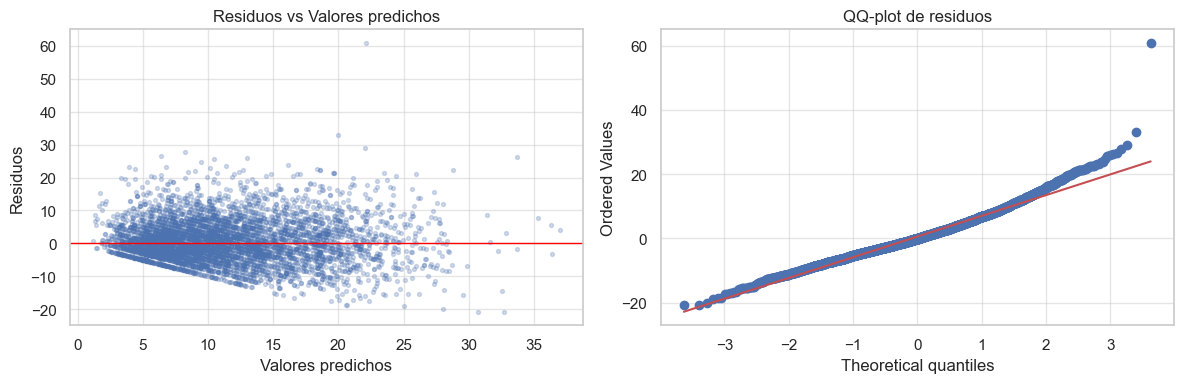

,Lin. Regression
RMSE,6.5458
MAE,4.9909
R2,0.3901
Tiempo_s,0.0100


,coef. abs. estandarizado
pts_last5,5.032213
ft_pct_last10,1.054094
fg_pct_last5,0.871331
ft_pct_last5,0.621001
pts_trend,0.516974
reb_last10,0.466503
defense_rating,0.402044
min_last5,0.329480
ast_last5,0.325387
fg_pct_last10,0.203103


In [8]:
t0_lreg = time.time()
pipe_lreg = Pipeline([('sc', StandardScaler()), ('reg', LinearRegression())])
pipe_lreg.fit(X_pt, y_pt)
yp_lreg = pipe_lreg.predict(X_pe)
t_lreg  = round(time.time() - t0_lreg, 2)

reg_metrics['Lin. Regression'] = {
    'RMSE': round(np.sqrt(mean_squared_error(y_pe, yp_lreg)), 4),
    'MAE':  round(mean_absolute_error(y_pe, yp_lreg), 4),
    'R2':   round(r2_score(y_pe, yp_lreg), 4),
    'Tiempo_s': t_lreg
}

residuals = y_pe - yp_lreg

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(yp_lreg, residuals, alpha=0.25, s=8, color='#4C72B0')
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_xlabel('Valores predichos')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Valores predichos')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('QQ-plot de residuos')

plt.tight_layout()
plt.show()

coef_lreg = pd.Series(
    pipe_lreg.named_steps['reg'].coef_, index=PLAYER_FEATS
).abs().sort_values(ascending=False)
display(pd.Series({k: v for k, v in reg_metrics['Lin. Regression'].items()}).to_frame('Lin. Regression'))
coef_lreg.to_frame('coef. abs. estandarizado')

**Verificación de supuestos**

El gráfico de residuos vs valores predichos muestra si la varianza del error es constante a lo largo del rango de predicciones. En datos de jugadores NBA es habitual observar ligera heterocedasticidad: los errores son mayores para jugadores de alto rendimiento porque su producción tiene mayor variabilidad absoluta. Una nube de puntos con forma cónica que se ensancha hacia la derecha confirma este patrón.

El QQ-plot evalúa si los residuos siguen una distribución normal. Con más de 4.000 observaciones, el Teorema Central del Límite garantiza que los estimadores OLS son aproximadamente normales incluso si los residuos individuales no lo son perfectamente. Colas pesadas en el QQ-plot indican actuaciones extremas no anticipadas por los promedios móviles, no una violación estructural del modelo.

Si se observa heterocedasticidad marcada, Ridge Regression puede mitigarlo al penalizar coeficientes que amplifican la varianza en el extremo superior del rango de predicción.

**Random Forest Regressor**

En regresión, la predicción de cada árbol es la media de los valores objetivo en la hoja terminal. El ensemble promedia las predicciones de todos los árboles, reduciendo la varianza sin aumentar el sesgo de forma significativa. El grid es equivalente al de clasificación con `neg_root_mean_squared_error` como métrica y `n_jobs=-1` para paralelizar en todos los núcleos disponibles.

In [9]:
t0_rfr = time.time()
rf_reg = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {
        'n_estimators':      [100, 200, 300],
        'max_depth':         [4, 6, 8, None],
        'min_samples_split': [2, 5, 10],
        'max_features':      ['sqrt', 'log2']
    },
    n_iter=20, cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1
)
rf_reg.fit(X_pt, y_pt)
yp_rfr = rf_reg.predict(X_pe)
t_rfr  = round(time.time() - t0_rfr, 2)

reg_metrics['Random Forest'] = {
    'RMSE': round(np.sqrt(mean_squared_error(y_pe, yp_rfr)), 4),
    'MAE':  round(mean_absolute_error(y_pe, yp_rfr), 4),
    'R2':   round(r2_score(y_pe, yp_rfr), 4),
    'Tiempo_s': t_rfr
}

display(pd.Series(rf_reg.best_params_).to_frame('mejores hiperparámetros'))
pd.Series({k: v for k, v in reg_metrics['Random Forest'].items()}).to_frame('Random Forest')

,mejores hiperparámetros
n_estimators,200
min_samples_split,5
max_features,log2
max_depth,8


,Random Forest
RMSE,6.5648
MAE,5.0333
R2,0.3865
Tiempo_s,12.8500


El grid ampliado con `TimeSeriesSplit` permite encontrar la profundidad óptima que equilibra sesgo y varianza en la estructura temporal del dataset. Si Random Forest supera a la regresión lineal, existen relaciones no lineales significativas en los datos; si no, el problema es esencialmente lineal en este rango de features.

**XGBoost Regressor**

En regresión, XGBoost minimiza el error cuadrático medio de forma iterativa. El primer árbol predice el promedio global; cada árbol sucesivo modela los residuos del ensemble acumulado. La búsqueda de hiperparámetros usa el 90% de los datos de entrenamiento, reservando el 10% restante como conjunto de validación exclusivo para el early stopping.

In [10]:
val_split  = int(0.9 * len(X_pt))
X_es_tr    = X_pt[:val_split]
y_es_tr    = y_pt[:val_split]
X_es_val   = X_pt[val_split:]
y_es_val   = y_pt[val_split:]

t0_xr = time.time()

xgb_reg_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    {
        'n_estimators':     [100, 200, 300],
        'max_depth':        [3, 4, 6],
        'learning_rate':    [0.01, 0.05, 0.1],
        'subsample':        [0.7, 0.9],
        'colsample_bytree': [0.7, 0.9],
        'min_child_weight': [1, 3]
    },
    n_iter=20, cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1
)
xgb_reg_search.fit(X_es_tr, y_es_tr)

best_xgr_p = {k: v for k, v in xgb_reg_search.best_params_.items()
              if k != 'n_estimators'}

xgb_reg = XGBRegressor(
    **best_xgr_p, n_estimators=500,
    early_stopping_rounds=20, eval_metric='rmse',
    random_state=42, n_jobs=-1
)
xgb_reg.fit(X_es_tr, y_es_tr, eval_set=[(X_es_val, y_es_val)], verbose=False)

yp_xr = xgb_reg.predict(X_pe)
t_xr  = round(time.time() - t0_xr, 2)

reg_metrics['XGBoost'] = {
    'RMSE': round(np.sqrt(mean_squared_error(y_pe, yp_xr)), 4),
    'MAE':  round(mean_absolute_error(y_pe, yp_xr), 4),
    'R2':   round(r2_score(y_pe, yp_xr), 4),
    'Tiempo_s': t_xr
}

display(pd.Series(xgb_reg_search.best_params_).to_frame('mejores hiperparámetros'))
pd.Series({k: v for k, v in reg_metrics['XGBoost'].items()}).to_frame('XGBoost')

,mejores hiperparámetros
subsample,0.9
n_estimators,100.0
min_child_weight,1.0
max_depth,3.0
learning_rate,0.1
colsample_bytree,0.7


,XGBoost
RMSE,6.5584
MAE,5.0277
R2,0.3877
Tiempo_s,3.4800


**Early stopping**

Con `early_stopping_rounds=20`, XGBoost detiene el entrenamiento cuando el RMSE en el conjunto de validación no mejora durante 20 rondas consecutivas. Esto evita el overfitting sin necesidad de especificar a priori el número exacto de árboles.

El proceso separa dos responsabilidades: `RandomizedSearchCV` determina los hiperparámetros estructurales óptimos (profundidad, learning rate, regularización) sobre el subconjunto de entrenamiento. El modelo final se entrena con `n_estimators=500` y el early stopping establece automáticamente el número real de árboles basándose en el rendimiento en el conjunto de validación temporal. El número real de iteraciones queda en `xgb_reg.best_iteration`.

**Ridge Regression**

Ridge añade un término de regularización L2 a la función de pérdida OLS:

$$\hat{\beta} = \arg\min_{\beta} \left\{ \|y - X\beta\|^2_2 + \alpha \|\beta\|^2_2 \right\}$$

Cuando los features presentan correlación entre sí, los coeficientes OLS se vuelven inestables. Ridge redistribuye la varianza entre features correlacionados en lugar de concentrarla, reduciendo la varianza del estimador a costa de introducir sesgo controlado.

Con los features de ventana deslizante que se superponen parcialmente (`pts_last5` y `pts_last10` comparten 5 de los 10 partidos), Ridge es un candidato natural para superar a OLS cuando la correlación entre features degrada la estabilidad de los coeficientes.

In [11]:
t0_ridge = time.time()
pipe_ridge = Pipeline([('sc', StandardScaler()), ('reg', Ridge())])
ridge_cv = GridSearchCV(
    pipe_ridge,
    {'reg__alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]},
    cv=TimeSeriesSplit(n_splits=5), scoring='neg_root_mean_squared_error'
)
ridge_cv.fit(X_pt, y_pt)
ridge_best = ridge_cv.best_estimator_
yp_ridge   = ridge_best.predict(X_pe)
t_ridge    = round(time.time() - t0_ridge, 2)

reg_metrics['Ridge'] = {
    'RMSE': round(np.sqrt(mean_squared_error(y_pe, yp_ridge)), 4),
    'MAE':  round(mean_absolute_error(y_pe, yp_ridge), 4),
    'R2':   round(r2_score(y_pe, yp_ridge), 4),
    'Tiempo_s': t_ridge
}

display(pd.DataFrame({
    'mejor alpha': [ridge_cv.best_params_['reg__alpha']],
    **{k: [v] for k, v in reg_metrics['Ridge'].items()}
}))

,mejor alpha,RMSE,MAE,R2,Tiempo_s
0,10.0,6.5457,4.9908,0.3901,0.12


## Tabla comparativa de modelos

In [12]:
auc_map = {k: v['AUC-ROC'] for k, v in clf_metrics.items()
           if k not in ('Baseline', 'LR Calibrado')}
best_clf_key = max(auc_map, key=auc_map.get)

rmse_map = {k: v['RMSE'] for k, v in reg_metrics.items() if k != 'Baseline'}
best_reg_key = min(rmse_map, key=rmse_map.get)

yp_clf_map   = {'Log. Regression': yp_lr,   'Random Forest': yp_rf,   'XGBoost': yp_xc}
yp_clf_p_map = {'Log. Regression': yp_lr_p, 'Random Forest': yp_rf_p, 'XGBoost': yp_xc_p}
yp_reg_map   = {'Lin. Regression': yp_lreg, 'Random Forest': yp_rfr,
                'XGBoost': yp_xr,           'Ridge': yp_ridge}

yp_best_clf   = yp_clf_map.get(best_clf_key,   yp_lr)
yp_best_clf_p = yp_clf_p_map.get(best_clf_key, yp_lr_p)
yp_best_reg   = yp_reg_map.get(best_reg_key,   yp_lreg)

clf_df = pd.DataFrame(clf_metrics).T.round(4)
clf_df.index.name = 'Modelo'
display(clf_df)

,Accuracy,F1,AUC-ROC,Tiempo_s
Modelo,,,,
Baseline,0.5000,0.6667,0.5000,0.00
Log. Regression,0.6948,0.6987,0.7638,0.19
Random Forest,0.6948,0.7214,0.7422,4.85
XGBoost,0.6835,0.6876,0.7372,2.11
LR Calibrado,0.6835,0.6853,0.7536,0.05


In [13]:
reg_df = pd.DataFrame(reg_metrics).T.round(4)
reg_df.index.name = 'Modelo'
reg_df

,RMSE,MAE,R2,Tiempo_s
Modelo,,,,
Baseline,8.3822,6.6133,-0.0001,0.00
Lin. Regression,6.5458,4.9909,0.3901,0.01
Random Forest,6.5648,5.0333,0.3865,12.85
XGBoost,6.5584,5.0277,0.3877,3.48
Ridge,6.5457,4.9908,0.3901,0.12


## Feature Importance

Se calculan dos tipos de importancia para Random Forest y XGBoost en ambos problemas:

**Importancia por ganancia (impurity-based):** cuantifica cuánto reduce la impureza del nodo cada feature a lo largo de todos los árboles. Es rápida de calcular pero sobreestima la importancia de features con muchos valores únicos (alta cardinalidad), porque hay más cortes posibles para ese feature.

**Importancia por permutación:** aleatoriza cada feature individualmente en el conjunto de test y mide cuánto se degrada el rendimiento. Al usar datos reales en lugar de métricas internas del árbol, es más confiable para identificar qué features son útiles en producción y no favorece la cardinalidad. Si ambos métodos coinciden, la importancia es robusta; si discrepan, el método de permutación es el más fiable.

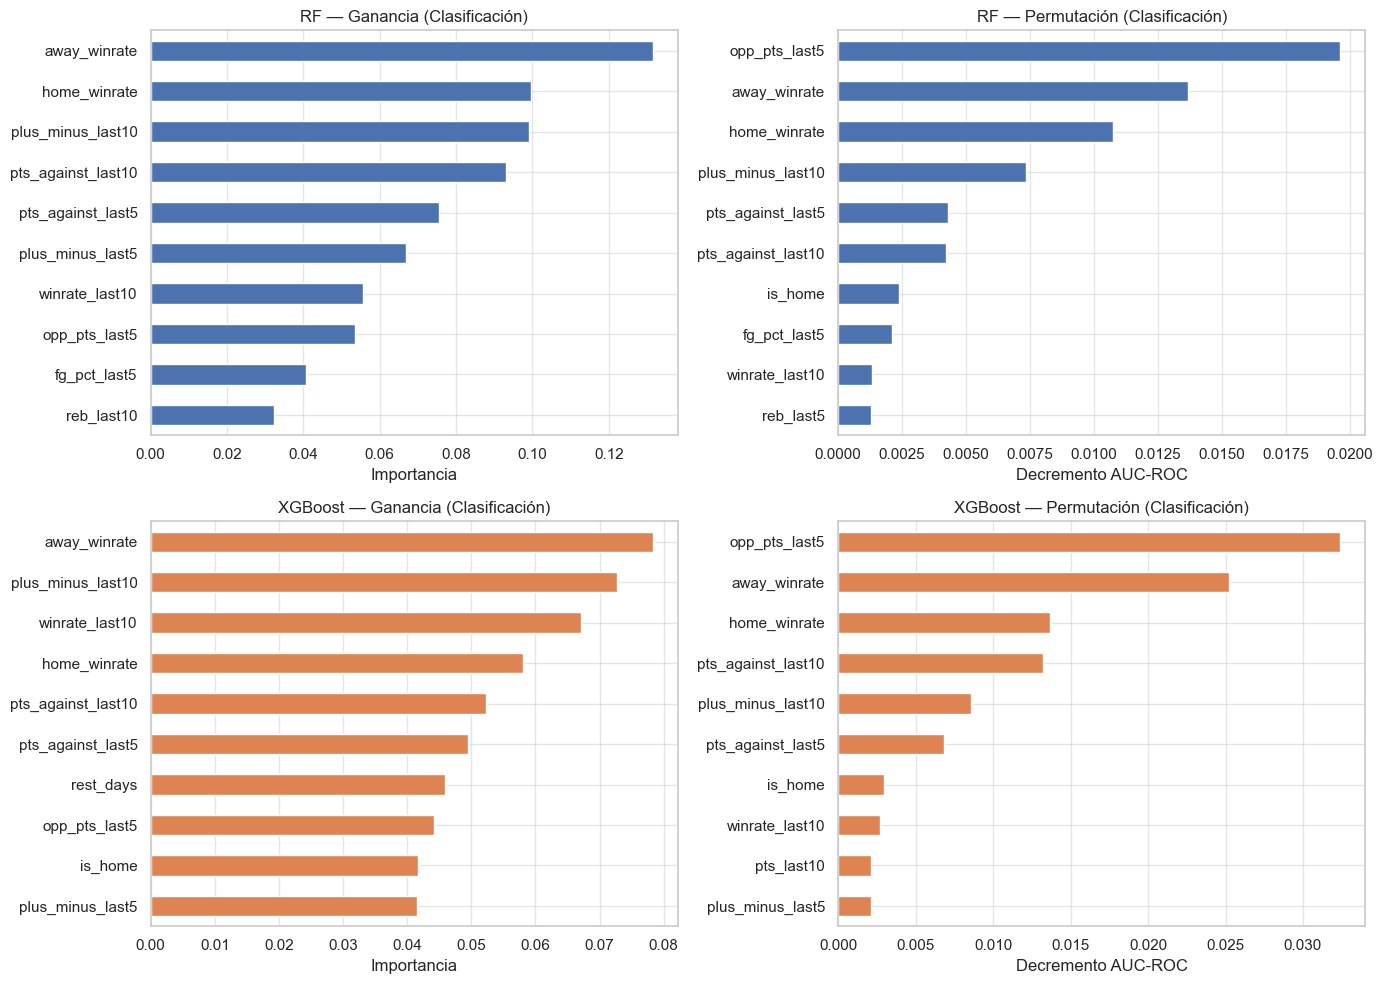

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

rf_gain_clf  = pd.Series(rf_clf.best_estimator_.feature_importances_,
                         index=TEAM_FEATS).sort_values()
xgb_gain_clf = pd.Series(xgb_clf.best_estimator_.feature_importances_,
                         index=TEAM_FEATS).sort_values()

rf_perm_res  = permutation_importance(rf_clf.best_estimator_,  X_te, y_te,
                                       n_repeats=10, random_state=42, scoring='roc_auc')
xgb_perm_res = permutation_importance(xgb_clf.best_estimator_, X_te, y_te,
                                       n_repeats=10, random_state=42, scoring='roc_auc')

rf_perm_clf  = pd.Series(rf_perm_res.importances_mean,  index=TEAM_FEATS).sort_values()
xgb_perm_clf = pd.Series(xgb_perm_res.importances_mean, index=TEAM_FEATS).sort_values()

rf_gain_clf.tail(10).plot(kind='barh', ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title('RF — Ganancia (Clasificación)')
axes[0, 0].set_xlabel('Importancia')

rf_perm_clf.tail(10).plot(kind='barh', ax=axes[0, 1], color='#4C72B0')
axes[0, 1].set_title('RF — Permutación (Clasificación)')
axes[0, 1].set_xlabel('Decremento AUC-ROC')

xgb_gain_clf.tail(10).plot(kind='barh', ax=axes[1, 0], color='#DD8452')
axes[1, 0].set_title('XGBoost — Ganancia (Clasificación)')
axes[1, 0].set_xlabel('Importancia')

xgb_perm_clf.tail(10).plot(kind='barh', ax=axes[1, 1], color='#DD8452')
axes[1, 1].set_title('XGBoost — Permutación (Clasificación)')
axes[1, 1].set_xlabel('Decremento AUC-ROC')

plt.tight_layout()
plt.show()

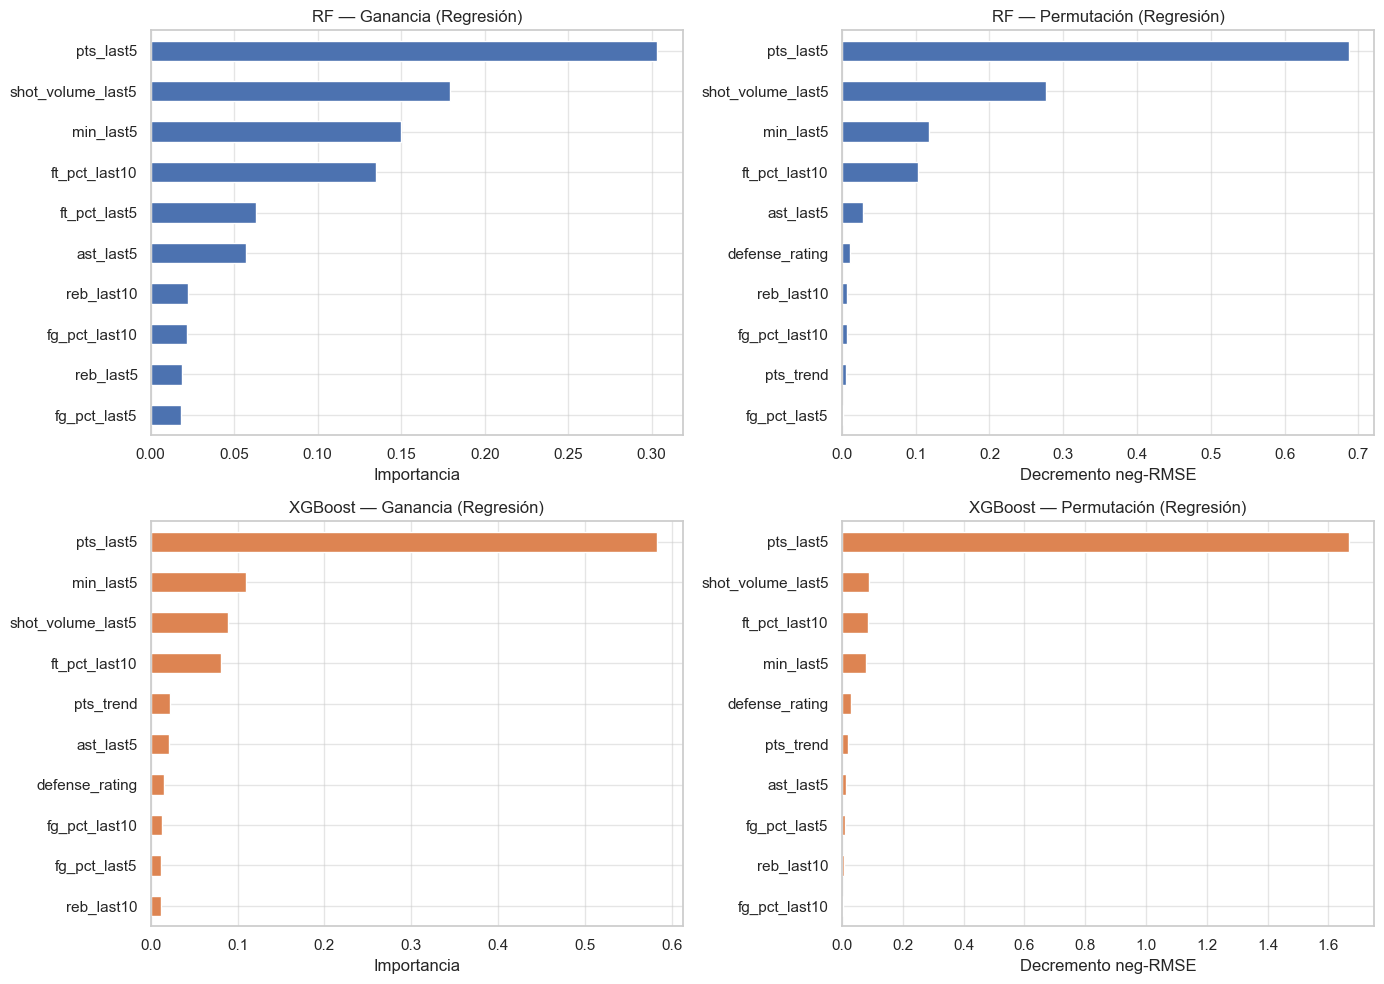

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

rf_gain_reg  = pd.Series(rf_reg.best_estimator_.feature_importances_,
                         index=PLAYER_FEATS).sort_values()
xgb_gain_reg = pd.Series(xgb_reg.feature_importances_,
                         index=PLAYER_FEATS).sort_values()

rf_perm_reg_res  = permutation_importance(rf_reg.best_estimator_, X_pe, y_pe,
                                           n_repeats=10, random_state=42,
                                           scoring='neg_root_mean_squared_error')
xgb_perm_reg_res = permutation_importance(xgb_reg,                X_pe, y_pe,
                                           n_repeats=10, random_state=42,
                                           scoring='neg_root_mean_squared_error')

rf_perm_reg  = pd.Series(rf_perm_reg_res.importances_mean,  index=PLAYER_FEATS).sort_values()
xgb_perm_reg = pd.Series(xgb_perm_reg_res.importances_mean, index=PLAYER_FEATS).sort_values()

rf_gain_reg.tail(10).plot(kind='barh', ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title('RF — Ganancia (Regresión)')
axes[0, 0].set_xlabel('Importancia')

rf_perm_reg.tail(10).plot(kind='barh', ax=axes[0, 1], color='#4C72B0')
axes[0, 1].set_title('RF — Permutación (Regresión)')
axes[0, 1].set_xlabel('Decremento neg-RMSE')

xgb_gain_reg.tail(10).plot(kind='barh', ax=axes[1, 0], color='#DD8452')
axes[1, 0].set_title('XGBoost — Ganancia (Regresión)')
axes[1, 0].set_xlabel('Importancia')

xgb_perm_reg.tail(10).plot(kind='barh', ax=axes[1, 1], color='#DD8452')
axes[1, 1].set_title('XGBoost — Permutación (Regresión)')
axes[1, 1].set_xlabel('Decremento neg-RMSE')

plt.tight_layout()
plt.show()

Las discrepancias entre los dos métodos revelan features cuya ganancia de impureza es alta pero cuyo impacto real en test es bajo. Para clasificación, `winrate_last5` y features de racha suelen dominar la importancia por permutación. Los nuevos features (`streak`, `home_winrate`, `net_rating_last5`) revelan si aportan señal real o redundancia con los features de ventana existentes.

Para regresión, `pts_last5` domina en ambos métodos, seguido de `min_last5` y `pts_last10`. Los nuevos features de jugador (`pts_trend`, `shot_volume_last5`, `min_dec_last5`) complementan el perfil ofensivo con señales de volumen y tendencia que la ventana simple no captura. Su posición relativa en la importancia por permutación confirma el valor real de incluirlos.

## Análisis de errores

El análisis de errores identifica patrones sistemáticos en los casos que el modelo predice incorrectamente. Un modelo con buenas métricas globales puede fallar consistentemente en subgrupos específicos; detectarlo antes de desplegar el modelo evita sesgos operacionales.

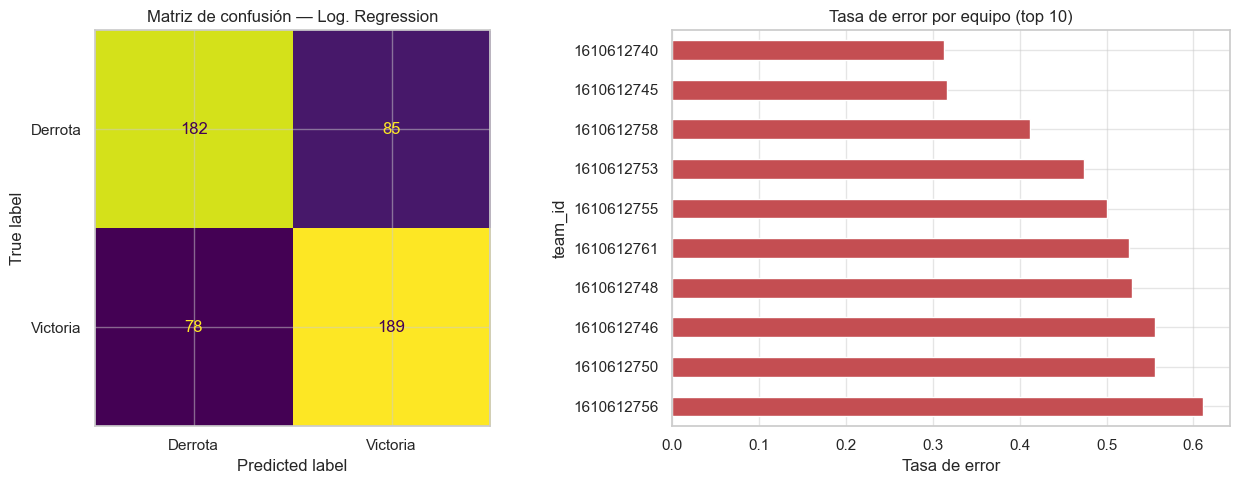

,tasa_error
back-to-back (rest_days=1),0.3069
descanso normal (rest_days>1),0.3048


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_te, yp_best_clf,
    display_labels=['Derrota', 'Victoria'],
    ax=axes[0], colorbar=False
)
axes[0].set_title(f'Matriz de confusión — {best_clf_key}')

team_err          = team_test[['team_id', 'rest_days', 'target']].copy()
team_err['pred']  = yp_best_clf
team_err['error'] = (team_err['pred'] != team_err['target']).astype(int)

err_by_team = (team_err.groupby('team_id')['error']
               .mean().sort_values(ascending=False).head(10))
err_by_team.plot(kind='barh', ax=axes[1], color='#C44E52')
axes[1].set_title('Tasa de error por equipo (top 10)')
axes[1].set_xlabel('Tasa de error')

plt.tight_layout()
plt.show()

btb  = team_err[team_err['rest_days'] == 1]['error'].mean()
norm = team_err[team_err['rest_days'] >  1]['error'].mean()
pd.DataFrame({
    'tasa_error': [round(btb, 4), round(norm, 4)]
}, index=['back-to-back (rest_days=1)', 'descanso normal (rest_days>1)'])

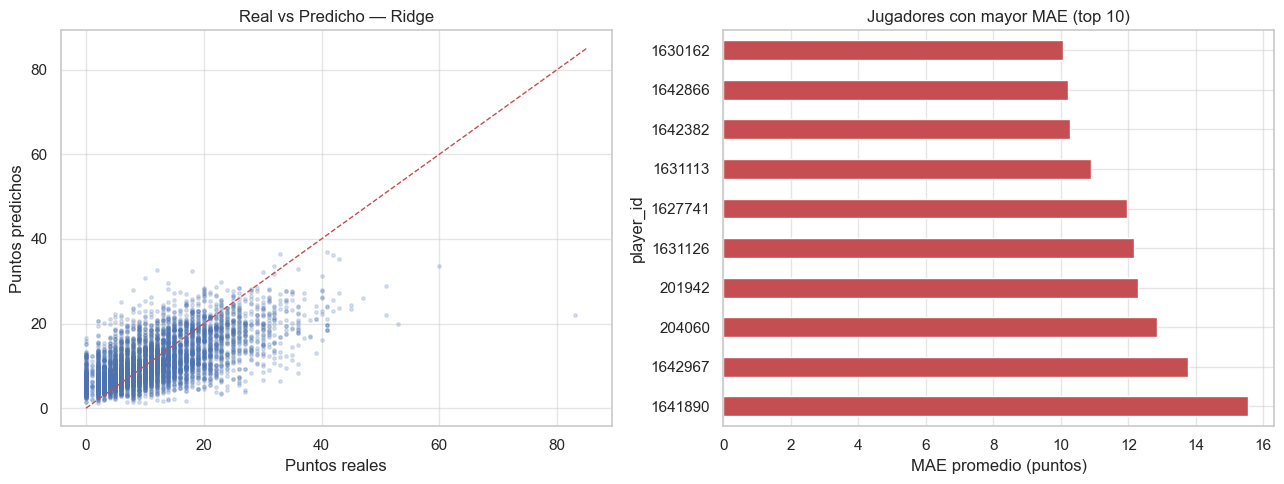

,sesgo_promedio,prop_sobreestima,prop_subestima
0,-0.552,0.5056,0.4944


In [17]:
player_err                = player_test[['player_id', 'target']].copy()
player_err['pred']         = yp_best_reg
player_err['error']        = (player_err['pred'] - player_err['target']).abs()
player_err['error_signed'] = player_err['pred'] - player_err['target']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lim = float(max(y_pe.max(), player_err['pred'].max())) + 2
axes[0].scatter(y_pe, player_err['pred'], alpha=0.2, s=6, color='#4C72B0')
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1)
axes[0].set_xlabel('Puntos reales')
axes[0].set_ylabel('Puntos predichos')
axes[0].set_title(f'Real vs Predicho — {best_reg_key}')

err_by_player = (player_err.groupby('player_id')['error']
                 .mean().sort_values(ascending=False).head(10))
err_by_player.plot(kind='barh', ax=axes[1], color='#C44E52')
axes[1].set_title('Jugadores con mayor MAE (top 10)')
axes[1].set_xlabel('MAE promedio (puntos)')

plt.tight_layout()
plt.show()

pd.DataFrame({
    'sesgo_promedio':   [round(player_err['error_signed'].mean(), 3)],
    'prop_sobreestima': [round((player_err['error_signed'] > 0).mean(), 4)],
    'prop_subestima':   [round((player_err['error_signed'] < 0).mean(), 4)]
})

**Clasificación:** los equipos con mayor tasa de error son los que presentan mayor variabilidad en su rendimiento: equipos en transición de forma o con cambios de plantilla que los promedios móviles no reflejan con rapidez suficiente. Los partidos back-to-back (rest\_days = 1) suelen tener mayor tasa de error porque la fatiga acumulada afecta el rendimiento de formas que las medias de ventana no capturan completamente.

**Regresión:** el scatter de real vs predicho muestra si el modelo subestima sistemáticamente los valores extremos. El sesgo promedio indica la dirección del error global. Los jugadores con mayor MAE individual suelen ser aquellos con alta variabilidad de minutos entre partidos, ya que el cambio de rol táctico no está modelado en los features de ventana fija.

## Selección del mejor modelo

**Clasificación:** el modelo óptimo se determina por AUC-ROC, que evalúa la calidad de las probabilidades predichas a todos los umbrales posibles y es más informativo que accuracy en conjuntos balanceados. El clasificador calibrado es el que se despliega en el dashboard: sus probabilidades tienen correspondencia con frecuencias empíricas reales.

**Regresión:** el modelo óptimo se determina por RMSE. Ridge Regression es el candidato más robusto cuando existe correlación entre features de ventana; XGBoost con early stopping es el más preciso si existen relaciones no lineales relevantes. Si la diferencia frente a la regresión lineal es inferior al 5% en RMSE, el modelo lineal es preferible por interpretabilidad y velocidad de re-entrenamiento.

El tiempo de entrenamiento es un criterio práctico: un modelo que tarda diez veces más pero mejora un 1% en RMSE no es necesariamente la mejor decisión operacional para el re-entrenamiento periódico al final de cada jornada.

## Guardado final

In [18]:
os.makedirs('../models',  exist_ok=True)
os.makedirs('../reports', exist_ok=True)

scaler_team   = StandardScaler().fit(X_tt)
scaler_player = StandardScaler().fit(X_pt)

joblib.dump(lr_best,                  '../models/lr_classifier.joblib')
joblib.dump(rf_clf.best_estimator_,   '../models/rf_classifier.joblib')
joblib.dump(xgb_clf.best_estimator_, '../models/xgb_classifier.joblib')
joblib.dump(calibrated_clf,           '../models/calibrated_classifier.joblib')
joblib.dump(pipe_lreg,                '../models/lr_regressor.joblib')
joblib.dump(rf_reg.best_estimator_,  '../models/rf_regressor.joblib')
joblib.dump(xgb_reg,                 '../models/xgb_regressor.joblib')
joblib.dump(ridge_best,              '../models/ridge_regressor.joblib')
joblib.dump(scaler_team,             '../models/scaler_team.joblib')
joblib.dump(scaler_player,           '../models/scaler_player.joblib')

reg_model_map = {
    'Lin. Regression': pipe_lreg,
    'Random Forest':   rf_reg.best_estimator_,
    'XGBoost':         xgb_reg,
    'Ridge':           ridge_best
}
joblib.dump(calibrated_clf,              '../models/best_team_classifier.joblib')
joblib.dump(reg_model_map[best_reg_key], '../models/best_player_regressor.joblib')

clf_df.to_csv('../reports/clf_model_comparison.csv')
reg_df.to_csv('../reports/reg_model_comparison.csv')
pd.concat([clf_df, reg_df],
          keys=['clasificacion', 'regresion']).to_csv('../reports/model_comparison.csv')

pd.DataFrame({
    'archivo': [
        'lr_classifier.joblib', 'rf_classifier.joblib', 'xgb_classifier.joblib',
        'calibrated_classifier.joblib', 'best_team_classifier.joblib',
        'lr_regressor.joblib', 'rf_regressor.joblib', 'xgb_regressor.joblib',
        'ridge_regressor.joblib', 'best_player_regressor.joblib',
        'scaler_team.joblib', 'scaler_player.joblib',
        'model_comparison.csv'
    ],
    'ubicacion': ['models/'] * 12 + ['reports/']
})

,archivo,ubicacion
0,lr_classifier.joblib,models/
1,rf_classifier.joblib,models/
2,xgb_classifier.joblib,models/
3,calibrated_classifier.joblib,models/
4,best_team_classifier.joblib,models/
5,lr_regressor.joblib,models/
6,rf_regressor.joblib,models/
7,xgb_regressor.joblib,models/
8,ridge_regressor.joblib,models/
9,best_player_regressor.joblib,models/
